# HPDM097 Assignment 2

## Iteration 6: Matplotlib code to visualise trade-off stepped curve (Gemini)

This is the 6th iteration to the code. Here we add Matplotlib code to visualise the trade-off stepped curve and increase the range of the acute beds to 0-26.

Prompt and response: https://gemini.google.com/share/e2275f74824c

## Prompt:
Yes please, maintaining the iterative approach and adding to the code above, add Matplotlib script to visualise the output table as a stepped trade-off curve and use a range of 0 - 26 beds

## Response
Visualizing the data is exactly what we need to make these capacity decisions intuitive. A stepped trade-off curve perfectly illustrates the non-linear relationship between adding beds and reducing patient delays. As you add beds, the marginal benefit (reduction in delay) shrinks, eventually plateauing.

I have updated the Scenario class to evaluate bed capacities from 0 to 26. I've also integrated matplotlib.pyplot at the end of the script, using the plt.step() function to correctly render the data as a stepped curve rather than a continuous line, which accurately reflects that beds are discrete units.

Here is the updated, integrated code:

--- Running Simulation (3 Year Warm-up + 10 Year Run) ---

--- Post-Warmup P(delay) Analysis for Acute Beds ---
Mean Unconstrained Acute Occupancy: 8.17 beds

Capacity | P(delay) | % Delayed
---------------------------------
      0  |  1.0000  |  100.00%
      1  |  0.8889  |   88.89%
      2  |  0.7568  |   75.68%
      3  |  0.6574  |   65.74%
      4  |  0.6412  |   64.12%
      5  |  0.5090  |   50.90%
      6  |  0.4233  |   42.33%
      7  |  0.3285  |   32.85%
      8  |  0.2440  |   24.40%
      9  |  0.1727  |   17.27%
     10  |  0.1371  |   13.71%
     11  |  0.0817  |    8.17%
     12  |  0.0592  |    5.92%
     13  |  0.0333  |    3.33%
     14  |  0.0206  |    2.06%
     15  |  0.0091  |    0.91%
     16  |  0.0066  |    0.66%
     17  |  0.0008  |    0.08%
     18  |  0.0003  |    0.03%
     19  |  0.0005  |    0.05%
     20  |  0.0003  |    0.03%
     21  |  0.0000  |    0.00%
     22  |  0.0000  |    0.00%
     23  |  0.0000  |    0.00%
     24  |  0.0000  |    0.00%


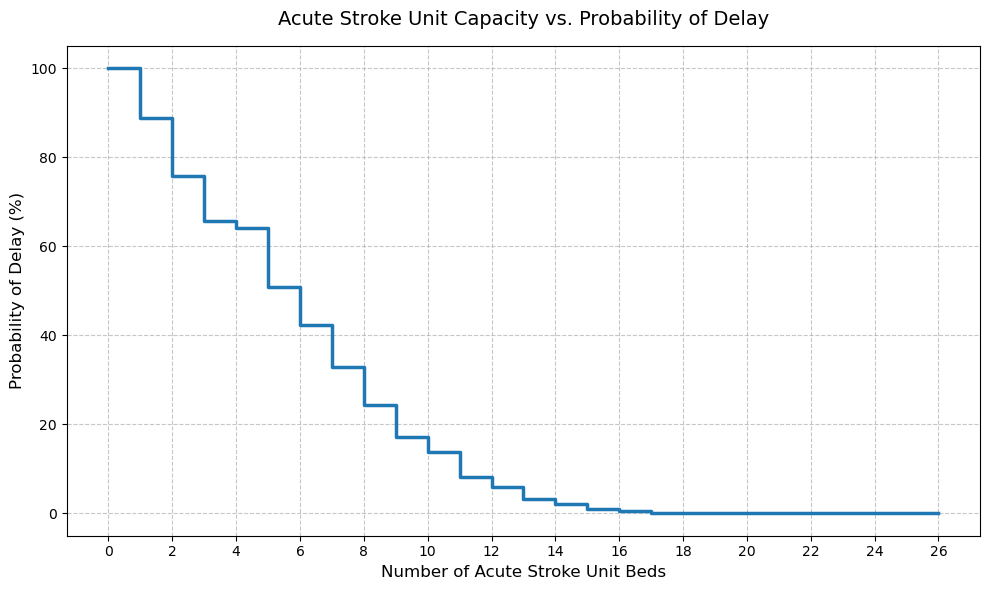

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Trace utility function as a debug print switch
# ---------------------------------------------------------
TRACE = False

def trace(msg):
    if TRACE:
        print(msg)

# ---------------------------------------------------------
# 1. Build and sample from distribution classes
# ---------------------------------------------------------
class ExponentialDistribution:
    def __init__(self, mean, random_seed=None):
        self.mean = mean
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.exponential(scale=self.mean)

class LognormalDistribution:
    def __init__(self, sample_mean, sample_stdev, random_seed=None):
        variance = sample_stdev ** 2
        self.mu = np.log((sample_mean ** 2) / np.sqrt(variance + sample_mean ** 2))
        self.sigma = np.sqrt(np.log(1 + (variance / sample_mean ** 2)))
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.lognormal(mean=self.mu, sigma=self.sigma)

# ---------------------------------------------------------
# 3. Create a parameter container class called Scenario
# ---------------------------------------------------------
class Scenario:
    def __init__(self):
        self.random_seed = 42
        
        # Simulation Runtime Parameters (Days)
        self.warm_up_days = 3 * 365
        self.run_days = 10 * 365
        
        # Unconstrained capacities to measure offered load
        self.acute_beds_capacity = 9999 
        self.rehab_beds_capacity = 9999 
        
        # Capacities to evaluate for the trade-off curve (0 to 26)
        self.capacity_eval_range = range(0, 27) 
        
        self.acute_inter_arrival_means = {
            'Acute stroke': 1.2, 'TIA': 9.3, 'Complex neurological': 3.6, 'Other': 3.2
        }
        
        self.rehab_inter_arrival_means = {
            'Acute stroke': 21.8, 'Complex neurological': 31.7, 'Other': 28.6
        }
        
        self.acute_destinations = ['Rehab', 'ESD', 'Other']
        self.acute_transfer_matrix = {
            'Acute stroke': [0.24, 0.13, 0.63], 'TIA': [0.01, 0.01, 0.98],
            'Complex neurological': [0.11, 0.05, 0.84], 'Other': [0.05, 0.10, 0.85]
        }
        
        self.rehab_destinations = ['ESD', 'Other']
        self.rehab_transfer_matrix = {
            'Acute stroke': [0.40, 0.60], 'TIA': [0.00, 1.00],
            'Complex neurological': [0.09, 0.91], 'Other': [0.13, 0.87] 
        }
        
        self.acute_los_params = {
            'Acute stroke': {'Rehab': (7.4, 8.6), 'ESD': (4.6, 4.8), 'Other': (7.4, 8.6)},
            'TIA': {dest: (1.8, 2.3) for dest in self.acute_destinations},
            'Complex neurological': {dest: (4.0, 5.0) for dest in self.acute_destinations},
            'Other': {dest: (3.8, 5.2) for dest in self.acute_destinations}
        }
        
        self.rehab_los_params = {
            'Acute stroke': {'ESD': (30.3, 23.1), 'Other': (28.4, 27.2)},
            'TIA': {dest: (18.7, 23.5) for dest in self.rehab_destinations},
            'Complex neurological': {dest: (27.6, 28.4) for dest in self.rehab_destinations},
            'Other': {dest: (16.1, 14.1) for dest in self.rehab_destinations}
        }

# ---------------------------------------------------------
# 4. Create a patient class called AcutePatient
# ---------------------------------------------------------
class AcutePatient:
    def __init__(self, p_id, p_type, arrival_time, source="Acute"):
        self.id = p_id
        self.type = p_type
        self.arrival_time = arrival_time
        self.source = source
        self.acute_destination = None
        self.acute_bed_request_time = None
        self.acute_bed_acquire_time = None
        self.acute_length_of_stay = None
        self.acute_discharge_time = None
        self.rehab_destination = None
        self.rehab_bed_request_time = None
        self.rehab_bed_acquire_time = None
        self.rehab_length_of_stay = None
        self.rehab_discharge_time = None

# ---------------------------------------------------------
# 5. Create a model class called StrokeUnit
# ---------------------------------------------------------
class StrokeUnit:
    def __init__(self, env, scenario):
        self.env = env
        self.scenario = scenario
        self.patient_counter = 0
        
        self.daily_acute_occupancy = []
        
        self.acute_beds = simpy.Resource(env, capacity=self.scenario.acute_beds_capacity)
        self.rehab_beds = simpy.Resource(env, capacity=self.scenario.rehab_beds_capacity)
        
        self.acute_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 100)
        self.rehab_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 200)
        
        self.acute_arrival_dists = {}
        self.rehab_arrival_dists = {}
        self.acute_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        self.rehab_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        
        dist_seed = self.scenario.random_seed + 1000
        
        for p_type, mean_iat in self.scenario.acute_inter_arrival_means.items():
            self.acute_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            for dest in self.scenario.acute_destinations:
                mean, stdev = self.scenario.acute_los_params[p_type][dest]
                self.acute_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1
                
        for p_type, mean_iat in self.scenario.rehab_inter_arrival_means.items():
            self.rehab_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            for dest in self.scenario.rehab_destinations:
                mean, stdev = self.scenario.rehab_los_params[p_type][dest]
                self.rehab_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1

    def daily_audit(self):
        """Waits for the warm-up period, then wakes up daily to record steady-state occupancy."""
        yield self.env.timeout(self.scenario.warm_up_days)
        trace(f"Day {self.env.now:06.2f} | Warm-up complete. Starting daily occupancy audits.")
        
        while True:
            self.daily_acute_occupancy.append(len(self.acute_beds.users))
            yield self.env.timeout(1.0)

    def acute_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.acute_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Acute")
            self.env.process(self.acute_process(patient))

    def rehab_direct_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.rehab_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Direct Rehab")
            self.env.process(self.rehab_process(patient))

    def acute_process(self, patient):
        probs = self.scenario.acute_transfer_matrix[patient.type]
        patient.acute_destination = self.acute_routing_rng.choice(self.scenario.acute_destinations, p=probs)
        patient.acute_bed_request_time = self.env.now
        
        with self.acute_beds.request() as req:
            yield req
            patient.acute_bed_acquire_time = self.env.now
            los = self.acute_los_dists[patient.type][patient.acute_destination].sample()
            patient.acute_length_of_stay = los
            yield self.env.timeout(los)
            patient.acute_discharge_time = self.env.now
            
            if patient.acute_destination == 'Rehab':
                self.env.process(self.rehab_process(patient))

    def rehab_process(self, patient):
        probs = self.scenario.rehab_transfer_matrix[patient.type]
        patient.rehab_destination = self.rehab_routing_rng.choice(self.scenario.rehab_destinations, p=probs)
        patient.rehab_bed_request_time = self.env.now
        
        with self.rehab_beds.request() as req:
            yield req
            patient.rehab_bed_acquire_time = self.env.now
            los = self.rehab_los_dists[patient.type][patient.rehab_destination].sample()
            patient.rehab_length_of_stay = los
            yield self.env.timeout(los)
            patient.rehab_discharge_time = self.env.now

    def run_simulation(self):
        self.env.process(self.daily_audit())
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            self.env.process(self.acute_arrivals_generator(p_type))
        for p_type in self.scenario.rehab_inter_arrival_means.keys():
            self.env.process(self.rehab_direct_arrivals_generator(p_type))

# =========================================================
# Analysis & Plotting Functions
# =========================================================
def calculate_p_delay_curve(occupancy_data, capacity_range):
    """Calculates Erlang P(delay) for a range of capacities based on steady-state occupancy."""
    if not occupancy_data:
        return {}
        
    max_eval_capacity = max(capacity_range)
    max_actual_occupancy = max(occupancy_data)
    array_size = max(max_eval_capacity, max_actual_occupancy) + 1
    
    counts = np.zeros(array_size)
    for occ in occupancy_data:
        counts[occ] += 1
        
    pdf = counts / len(occupancy_data)
    cdf = np.cumsum(pdf)
    
    results = {}
    for n in capacity_range:
        p_n = pdf[n]
        p_le_n = cdf[n]
        # Mathematical handling for P(delay): P(N=n) / P(N<=n)
        # Note: If n=0, cdf[0] == pdf[0], resulting in 1.0 (100% delay)
        p_delay = p_n / p_le_n if p_le_n > 0 else 0.0
        results[n] = p_delay
        
    return results

def plot_tradeoff_curve(p_delay_results):
    """Generates a stepped line chart of the P(delay) against bed capacity."""
    beds = list(p_delay_results.keys())
    # Convert probability to percentage for the y-axis
    p_delay_pct = [val * 100 for val in p_delay_results.values()] 
    
    plt.figure(figsize=(10, 6))
    
    # 'post' ensures the step holds the value until the next integer capacity
    plt.step(beds, p_delay_pct, where='post', color='#1f77b4', linewidth=2.5)
    
    plt.title('Acute Stroke Unit Capacity vs. Probability of Delay', fontsize=14, pad=15)
    plt.xlabel('Number of Acute Stroke Unit Beds', fontsize=12)
    plt.ylabel('Probability of Delay (%)', fontsize=12)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(beds[::2]) # Show every 2nd bed number on x-axis to avoid crowding
    plt.ylim(-5, 105)
    
    plt.tight_layout()
    plt.show()

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    scenario = Scenario()
    env = simpy.Environment()
    model = StrokeUnit(env, scenario)
    
    print(f"--- Running Simulation ({scenario.warm_up_days//365} Year Warm-up + {scenario.run_days//365} Year Run) ---")
    model.run_simulation()
    
    total_sim_time = scenario.warm_up_days + scenario.run_days
    env.run(until=total_sim_time)
    
    print(f"\n--- Post-Warmup P(delay) Analysis for Acute Beds ---")
    print(f"Mean Unconstrained Acute Occupancy: {np.mean(model.daily_acute_occupancy):.2f} beds\n")
    
    p_delay_results = calculate_p_delay_curve(model.daily_acute_occupancy, scenario.capacity_eval_range)
    
    print("Capacity | P(delay) | % Delayed")
    print("---------------------------------")
    for beds, p_delay in p_delay_results.items():
        print(f" {beds:6d}  |  {p_delay:.4f}  | {p_delay*100:7.2f}%")
        
    print("\nGenerating Matplotlib visualization...")
    plot_tradeoff_curve(p_delay_results)